In [7]:
# Imports and Setup

import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


sns.set_style("whitegrid")

# Exploratory Data Analysis

In [2]:
df = pd.read_csv('nhanes_all_processed.csv')
ref_ranges = pd.read_csv('reference_ranges.csv')

In [3]:
df.head()

,respondent_id,vitamin_d,alt,albumin,alp,ast,bun,creatine_kinase,creatinine_serum,ggt,...,poly_fat,sodium_diet,pulse,total_pa_mets_per_wk,drinks_per_week,avg_sleep_hrs,phq8_score,taking_aspirin,romberg_avg_time,map
0,130378.0,58.9,39.0,4.3,91.0,25.0,11.0,172.0,70.72,41.0,...,10.5535,2144.0,81.000000,1417.5,NaN,9.357143,NaN,0,15.0,108.222222
1,130379.0,60.5,17.0,3.9,64.0,20.0,24.0,98.0,69.84,31.0,...,24.1365,4536.5,72.000000,1575.0,18.000,9.000000,1.0,0,20.1,91.444444
2,130380.0,39.4,13.0,3.7,78.0,15.0,10.0,38.0,56.58,44.0,...,12.3670,2934.5,81.333333,NaN,0.029,8.285714,2.0,0,12.3,88.555556
3,130384.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.642857,NaN,0,NaN,NaN
4,130385.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,735.0,NaN,8.000000,NaN,0,NaN,NaN


In [4]:
ref_ranges.head()

,Variable Code,NHANES File,CRR_M_Low,CRR_M_High,CRR_F_Low,CRR_F_High,Units,Panel,Source
0,LBXGH,GHB_L.xpt,4.0,5.6,4.0,5.6,%,Metabolic,https://www.mayocliniclabs.com/test-catalog/ov...
1,LBXIN,INS_L.xpt,3.0,25.0,3.0,25.0,mcIU/mL,Metabolic,https://www.mayocliniclabs.com/test-catalog/ov...
2,LBXGLU,GLU_L.xpt,70.0,99.0,70.0,99.0,mg/dL,Metabolic,https://www.mayocliniclabs.com/test-catalog/ov...
3,LBXSUA,BIOPRO_L.xpt,3.5,8.0,2.5,6.1,mg/dL,Kidney,https://www.mayocliniclabs.com/test-catalog/ov...
4,LBXTLG,TRIGLY_L.xpt,0.0,199.0,0.0,199.0,mg/dL,Lipid,https://www.mayocliniclabs.com/test-catalog/ov...


In [5]:
print(df.columns)

Index(['respondent_id', 'vitamin_d', 'alt', 'albumin', 'alp', 'ast', 'bun',
       'creatine_kinase', 'creatinine_serum', 'ggt',
       ...
       'poly_fat', 'sodium_diet', 'pulse', 'total_pa_mets_per_wk',
       'drinks_per_week', 'avg_sleep_hrs', 'phq8_score', 'taking_aspirin',
       'romberg_avg_time', 'map'],
      dtype='object', length=128)


In [6]:
# ---------------------------
# 1. Sample Size
# ---------------------------
n = len(df)
print(f"Sample size (N): {n}")

# ---------------------------
# 2. Age
# ---------------------------
print("\nAge:")
print(f"Mean ± SD: {df['age_years'].mean():.1f} ± {df['age_years'].std():.1f}")
print(f"Median (IQR): {df['age_years'].median():.1f} ({df['age_years'].quantile(0.25):.1f}–{df['age_years'].quantile(0.75):.1f})")

# ---------------------------
# 3. Sex
# ---------------------------
print("\nSex (%):")
sex_pct = df['gender'].value_counts(normalize=True) * 100
print(sex_pct.round(1))

# ---------------------------
# 4. Race/Ethnicity
# ---------------------------
print("\nRace/Ethnicity (%):")
race_pct = df['race_ethnicity'].value_counts(normalize=True) * 100
print(race_pct.round(1))

# ---------------------------
# 5. Income (PIR)
# ---------------------------
if 'income_poverty_ratio' in df.columns:
    print("\nIncome (PIR):")
    print(f"Mean ± SD: {df['income_poverty_ratio'].mean():.2f} ± {df['income_poverty_ratio'].std():.2f}")

# ---------------------------
# 6. BMI (or other clinical)
# ---------------------------
if 'bmi' in df.columns:
    print("\nBMI:")
    print(f"Mean ± SD: {df['bmi'].mean():.1f} ± {df['bmi'].std():.1f}")

# Optional BMI categories
    bmi_cat = pd.cut(df['bmi'],
                     bins=[0, 18.5, 25, 30, np.inf],
                     labels=["Underweight", "Normal", "Overweight", "Obese"])
    print("\nBMI Categories (%):")
    print((bmi_cat.value_counts(normalize=True) * 100).round(1))



Sample size (N): 7587

Age:
Mean ± SD: 50.3 ± 17.6
Median (IQR): 53.0 (35.0–65.0)

Sex (%):
gender
1.0    54.9
0.0    45.1
Name: proportion, dtype: float64

Race/Ethnicity (%):
race_ethnicity
3.0    56.7
4.0    13.1
2.0    10.1
1.0     7.7
7.0     6.8
6.0     5.5
Name: proportion, dtype: float64

Income (PIR):
Mean ± SD: 2.89 ± 1.68

BMI:
Mean ± SD: 29.8 ± 7.5

BMI Categories (%):
bmi
Obese          40.7
Overweight     30.9
Normal         26.5
Underweight     1.9
Name: proportion, dtype: float64


C:\Users\domin\AppData\Local\Temp\ipykernel_25124\287855871.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=race_pct.values, y=race_pct.index, palette="Blues")
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to s

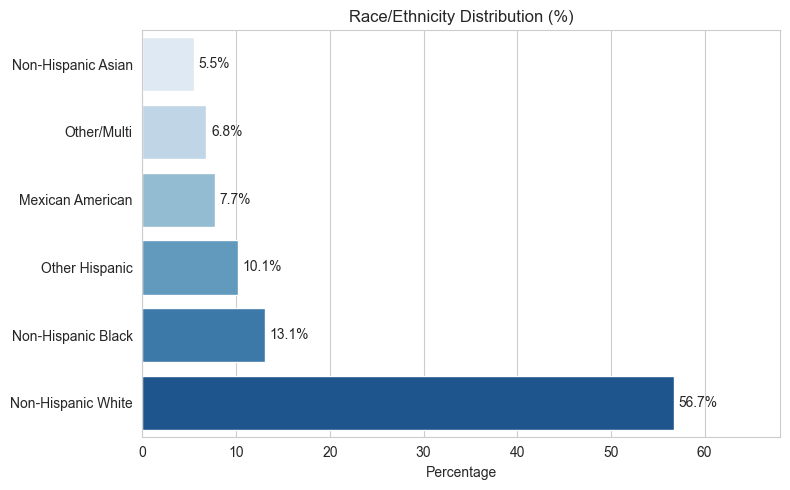

In [8]:
# Map race codes to labels (adjust if needed)
race_map = {
    1.0: "Mexican American",
    2.0: "Other Hispanic",
    3.0: "Non-Hispanic White",
    4.0: "Non-Hispanic Black",
    6.0: "Non-Hispanic Asian",
    7.0: "Other/Multi"
}

df['race_label'] = df['race_ethnicity'].map(race_map)

# Calculate percentages
race_pct = (
    df['race_label']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values()
)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=race_pct.values, y=race_pct.index, palette="Blues")

plt.title("Race/Ethnicity Distribution (%)")
plt.xlabel("Percentage")
plt.ylabel("")
plt.xlim(0, race_pct.max() * 1.2)

# Add labels on bars
for i, v in enumerate(race_pct.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()

C:\Users\domin\AppData\Local\Temp\ipykernel_25124\513980444.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bmi_pct.index, y=bmi_pct.values, palette="Blues")
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to sil

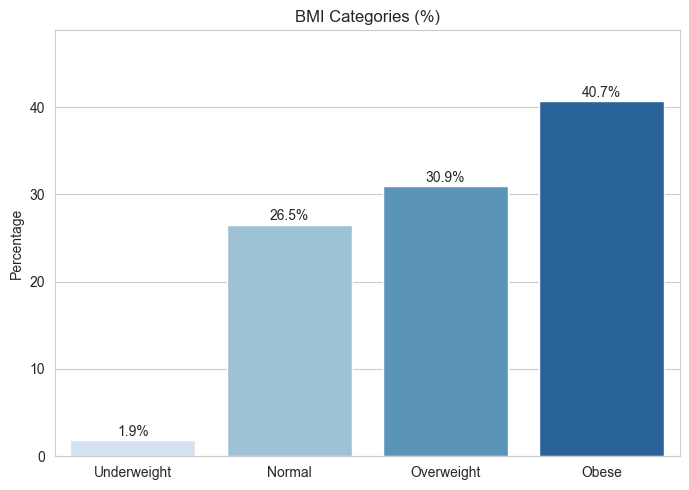

In [9]:
# Create BMI categories
bmi_cat = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Calculate percentages (ordered)
bmi_pct = (
    bmi_cat
    .value_counts(normalize=True)
    .reindex(["Underweight", "Normal", "Overweight", "Obese"])
    .mul(100)
)

# Plot
plt.figure(figsize=(7, 5))
sns.barplot(x=bmi_pct.index, y=bmi_pct.values, palette="Blues")

plt.title("BMI Categories (%)")
plt.xlabel("")
plt.ylabel("Percentage")
plt.ylim(0, bmi_pct.max() * 1.2)

# Add labels
for i, v in enumerate(bmi_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

In [10]:
test_names = {
    "LBXVIDMS":  "vitamin_d",
    "LBXSATSI":  "alt",
    "LBXSAL":    "albumin",
    "LBXSAPSI":  "alp",
    "LBXSASSI":  "ast",
    "LBXSBU":    "bun",
    "LBXSGTSI":  "ggt",
    "LBXSUA":    "uric_acid",

    # LAB: OTHER
    "LBXHSCRP":  "hscrp",
    "LBXGH":     "hba1c",
    "LBXFER":    "ferritin",
    "LBXWBCSI":  "wbc",
    "LBXHGB":    "hemoglobin",
    "LBXHCT":    "hematocrit",
    "LBXTC":     "cholesterol_total",
    "LBXTLG":    "triglycerides",
    "LBDLDLN":   "ldl_cholesterol",
    "LBDHDD":    "hdl_cholesterol",
    'LBXHSCRP':'hscrp', # High-sensitivity CRP (mg/L)
    }

In [11]:
for i in ref_ranges['Variable Code']:
  if i in test_names:
    ref_ranges.loc[ref_ranges['Variable Code'] == i, 'Variable Code'] = test_names[i]

In [12]:
ref_ranges.head()

,Variable Code,NHANES File,CRR_M_Low,CRR_M_High,CRR_F_Low,CRR_F_High,Units,Panel,Source
0,hba1c,GHB_L.xpt,4.0,5.6,4.0,5.6,%,Metabolic,https://www.mayocliniclabs.com/test-catalog/ov...
1,LBXIN,INS_L.xpt,3.0,25.0,3.0,25.0,mcIU/mL,Metabolic,https://www.mayocliniclabs.com/test-catalog/ov...
2,LBXGLU,GLU_L.xpt,70.0,99.0,70.0,99.0,mg/dL,Metabolic,https://www.mayocliniclabs.com/test-catalog/ov...
3,uric_acid,BIOPRO_L.xpt,3.5,8.0,2.5,6.1,mg/dL,Kidney,https://www.mayocliniclabs.com/test-catalog/ov...
4,triglycerides,TRIGLY_L.xpt,0.0,199.0,0.0,199.0,mg/dL,Lipid,https://www.mayocliniclabs.com/test-catalog/ov...


In [13]:
ref_ranges = ref_ranges.replace(999, np.nan)

In [14]:
ref_ranges['Variable Code']

0                 hba1c
1                 LBXIN
2                LBXGLU
3             uric_acid
4         triglycerides
5       ldl_cholesterol
6       hdl_cholesterol
7     cholesterol_total
8            hemoglobin
9            hematocrit
10                  wbc
11                  bun
12               LBXSCR
13                  ast
14                  alt
15                  alp
16              albumin
17               LBXSTB
18                  ggt
19            vitamin_d
20             ferritin
21                hscrp
Name: Variable Code, dtype: object

In [15]:
def plot_histplots(test_df, tests, ref_df=ref_ranges, filter_outliers=False):

    # Clean column names to avoid hidden whitespace issues
    ref_df = ref_df.copy()
    ref_df.columns = ref_df.columns.str.strip()
    ref_df['Variable Code'] = ref_df['Variable Code'].astype(str).str.strip()

    cols = 2
    rows = math.ceil(len(tests) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    axes = np.array(axes).flatten()

    gender_palette = {1: 'blue', 0: 'red'}

    for i, test in enumerate(tests):
        ax = axes[i]

        # Normalize test name for matching
        test_clean = str(test).strip()

        # Find matching reference row
        filtered = ref_df[ref_df['Variable Code'] == test_clean]

        if filtered.empty:
            print(f"Warning: '{test}' not found in ref_df['Variable Code']")
            ax.set_visible(False)
            continue

        ref_row = filtered.iloc[0]

        # Optional outlier filtering
        if filter_outliers and test in test_df.columns:
            Q1 = test_df[test].quantile(0.02)
            Q3 = test_df[test].quantile(0.98)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            plot_data = test_df[(test_df[test] >= lower_bound) & (test_df[test] <= upper_bound)]
        else:
            plot_data = test_df

        # Plot histogram
        sns.histplot(data=plot_data, x=test, ax=ax, hue='gender', palette=gender_palette)

        # Add reference lines
        ax.axvline(ref_row['CRR_M_Low'], color='blue', linestyle='--', label='Male Low')
        ax.axvline(ref_row['CRR_M_High'], color='blue', linestyle='--', label='Male High')
        ax.axvline(ref_row['CRR_F_Low'], color='red', linestyle='--', label='Female Low')
        ax.axvline(ref_row['CRR_F_High'], color='red', linestyle='--', label='Female High')

        # Title (safer access)
        units = ref_row.get("Units", "Unknown units")
        nhanes_code = ref_row.get("Variable Code", "N/A")

        ax.set_title(f"{test} ({units}) - NHANES Code: {nhanes_code}")
        ax.legend()

    # Hide unused axes
    for j in range(len(tests), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [16]:
tests = list(test_names.values())

In [17]:
df = df.drop(columns='race_label')

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


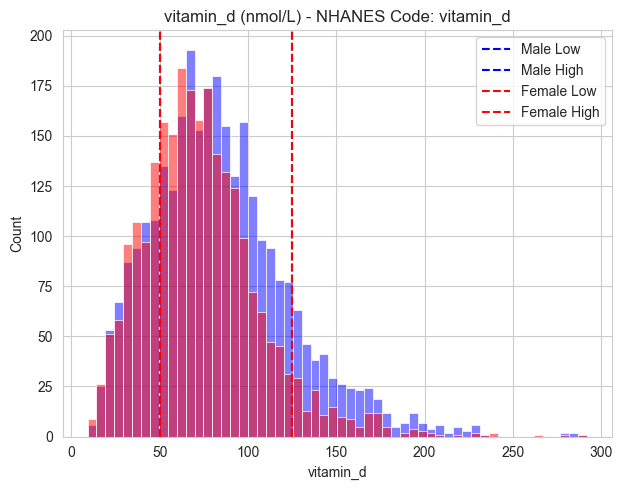

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


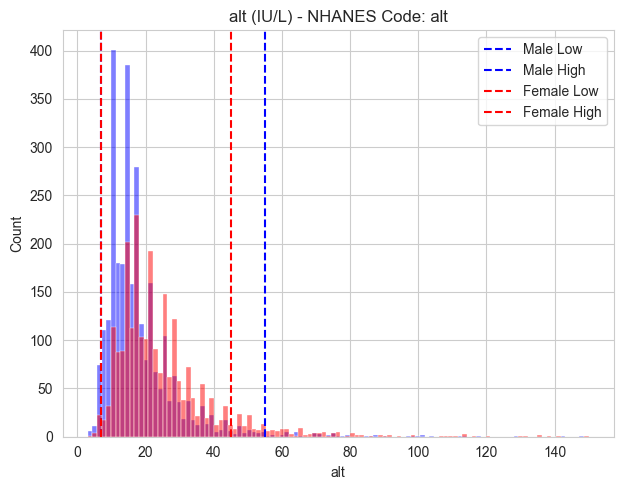

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


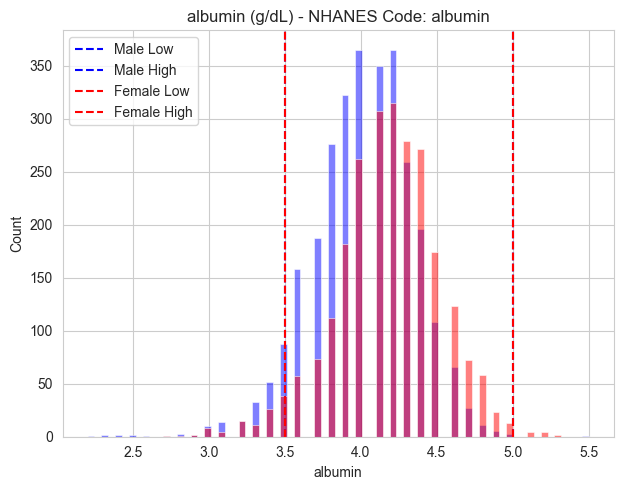

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


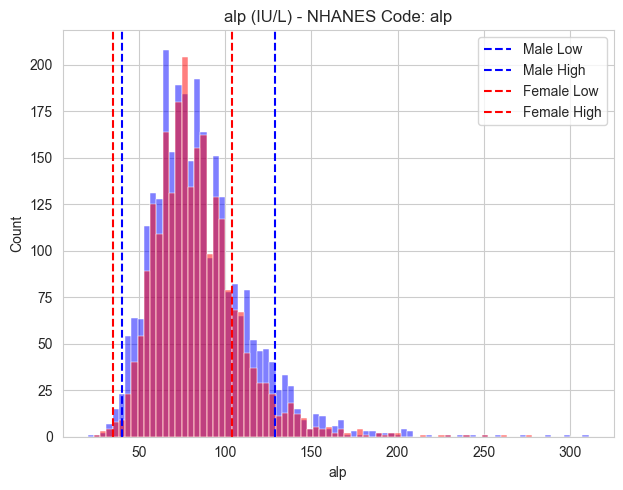

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


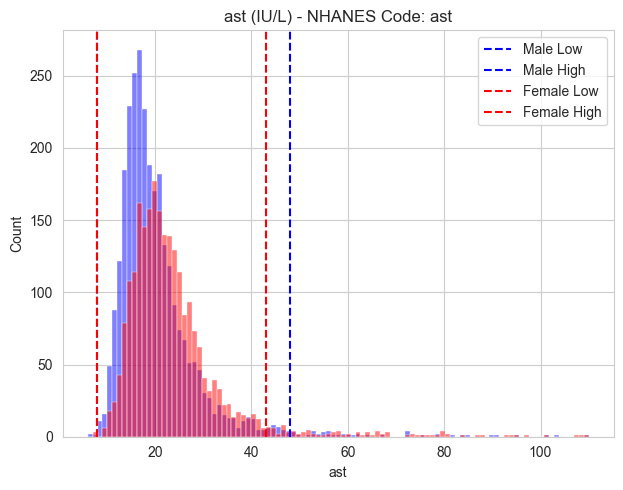

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


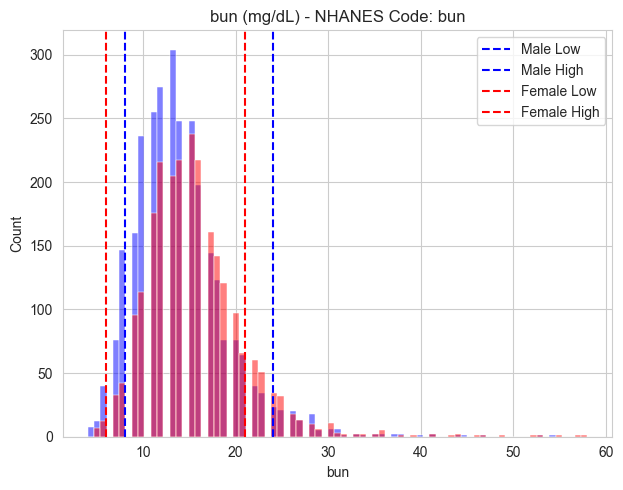

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


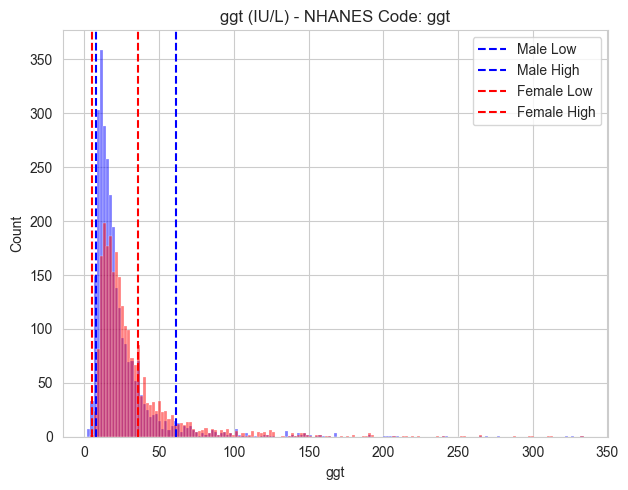

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


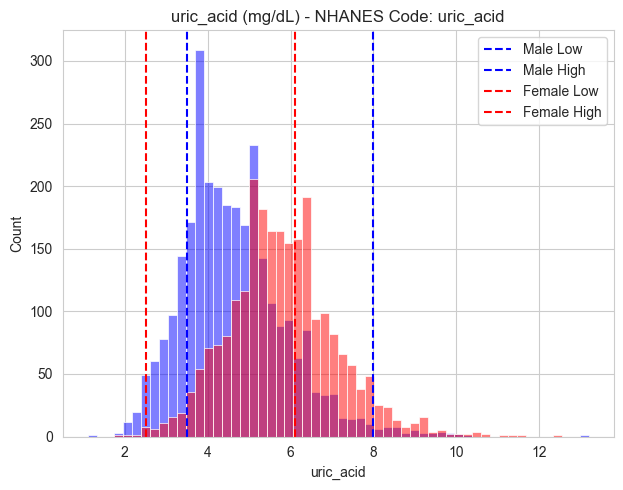

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


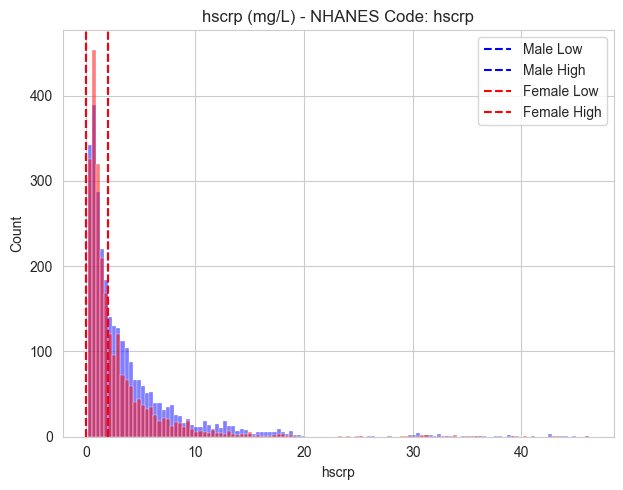

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


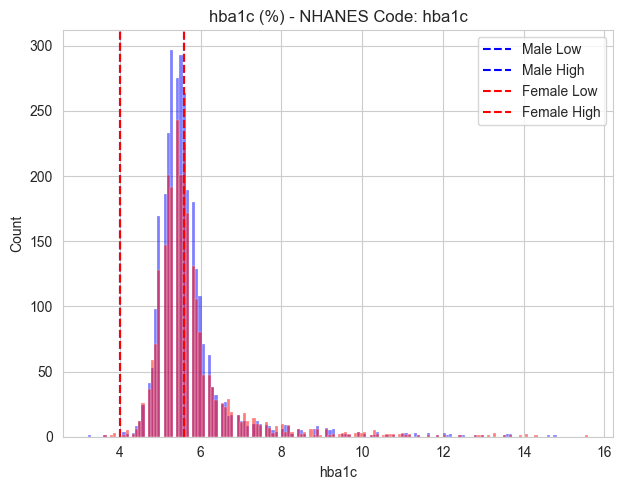

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


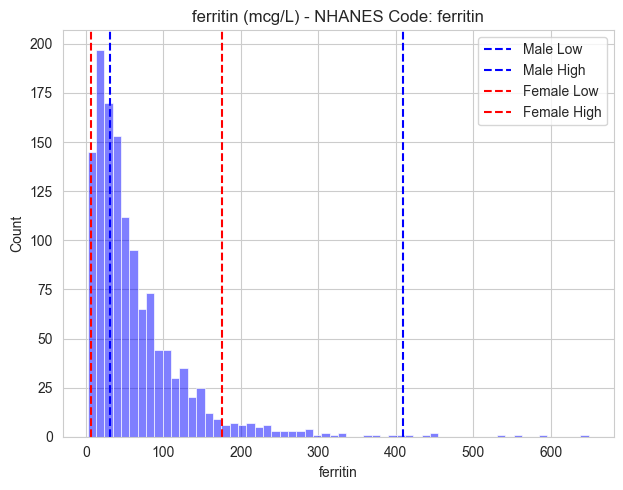

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


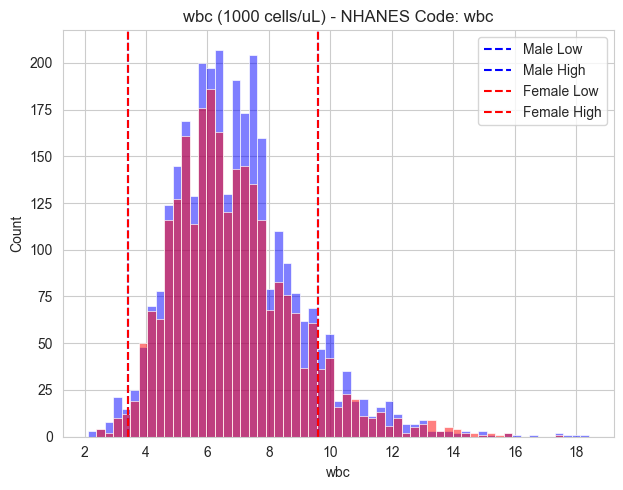

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


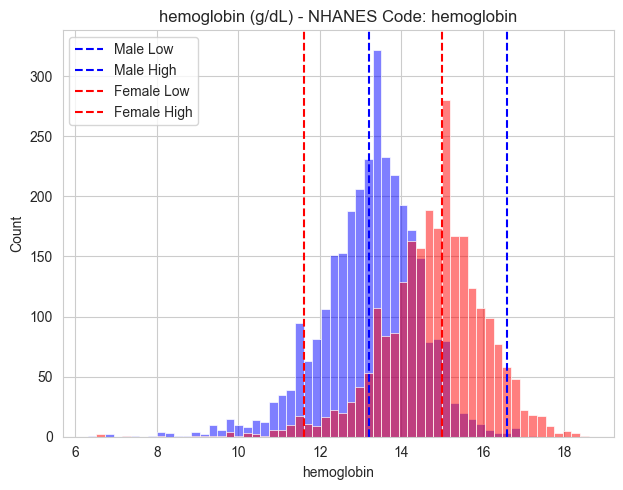

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


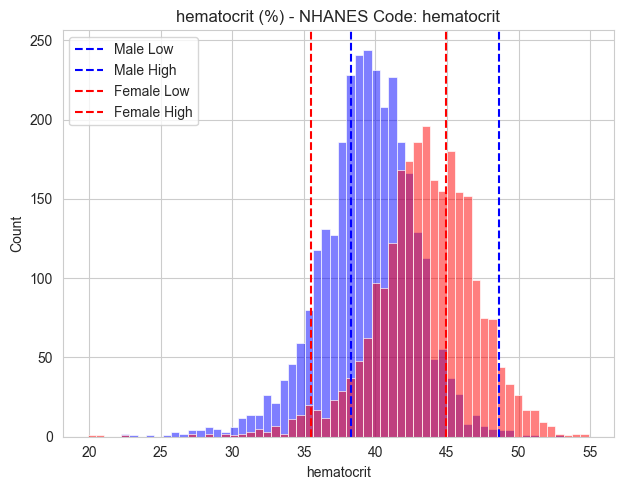

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


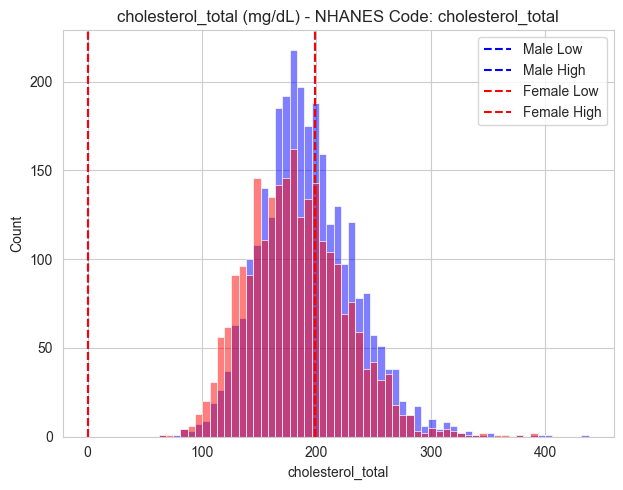

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


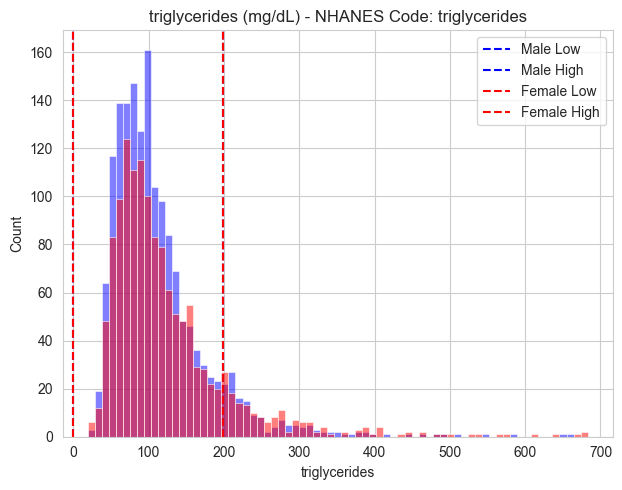

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


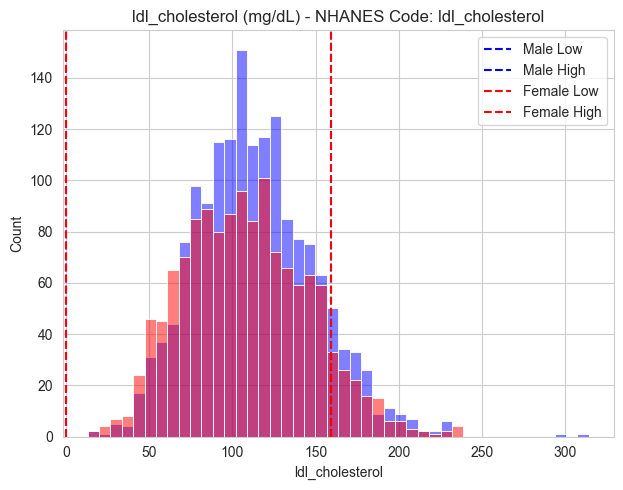

c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Software\Python\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


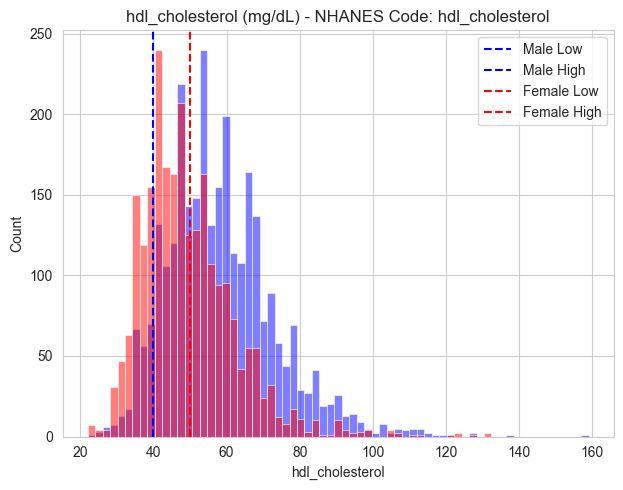

In [18]:
for col in df:
  if col in tests:
    plot_histplots(df, [col], filter_outliers=True)

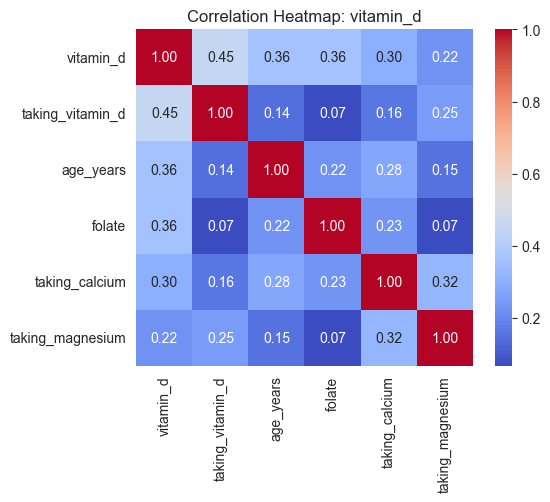

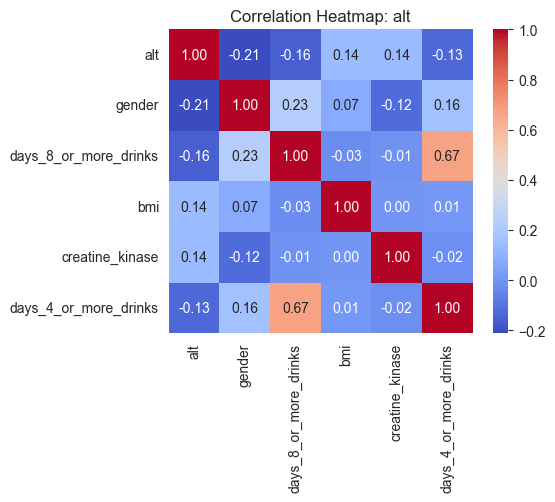

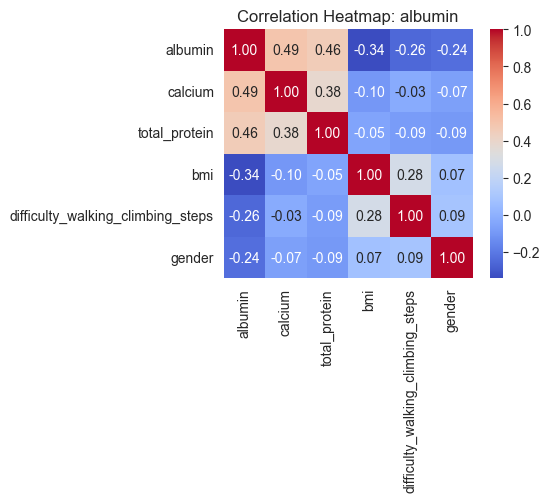

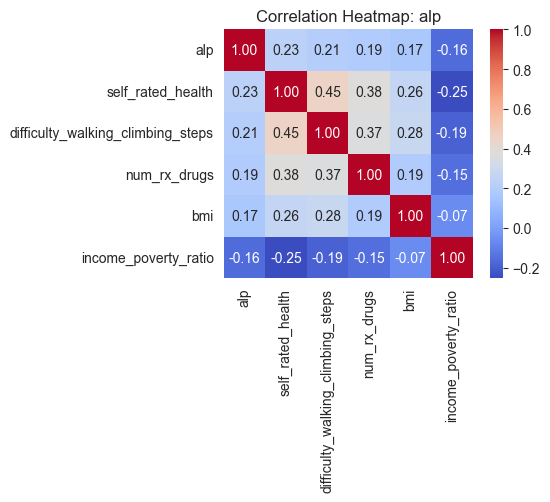

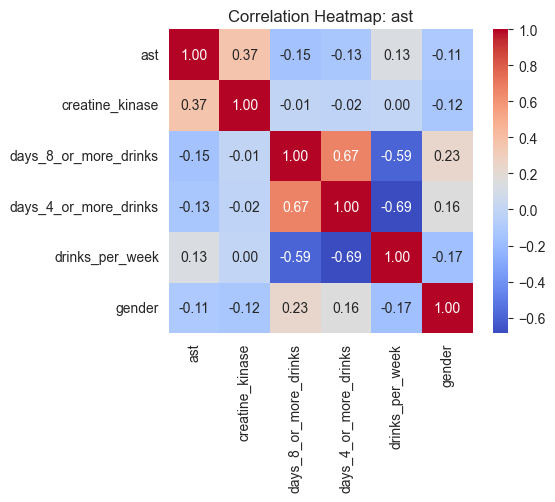

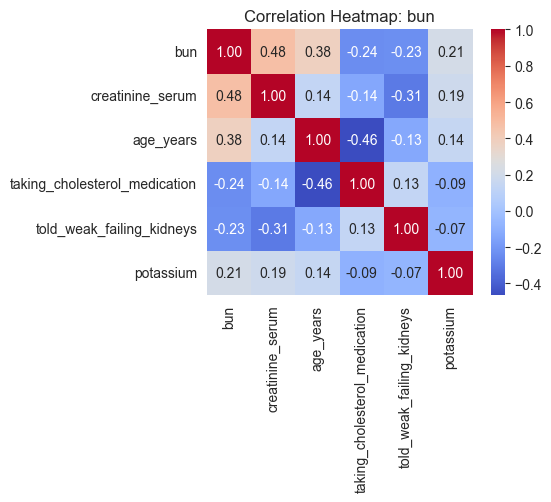

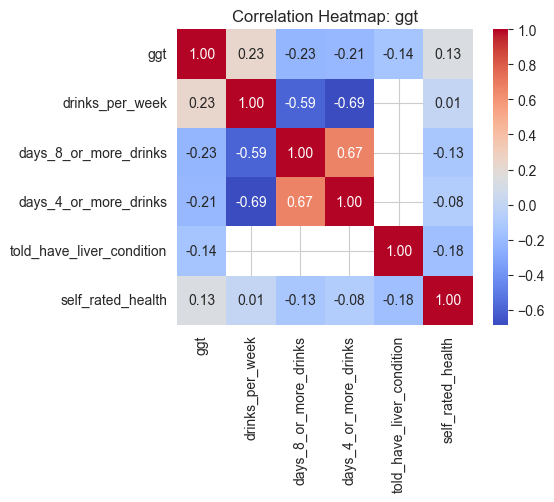

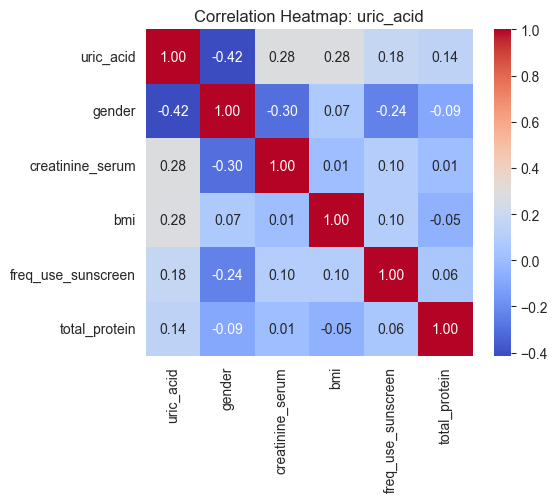

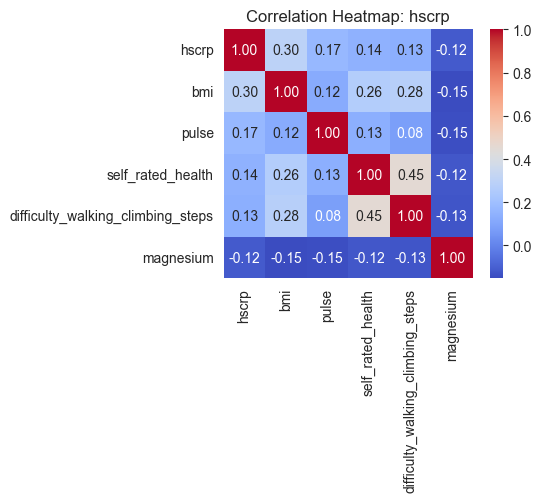

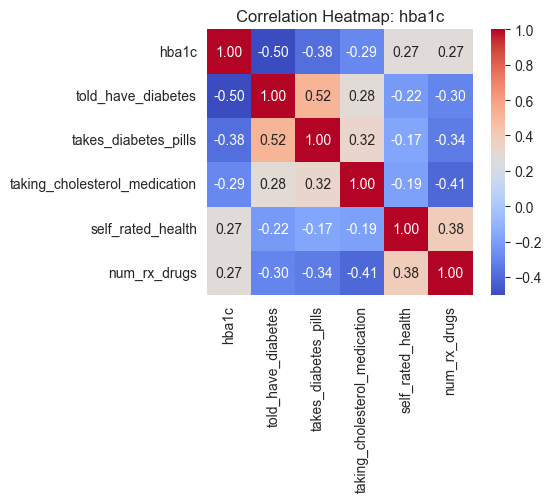

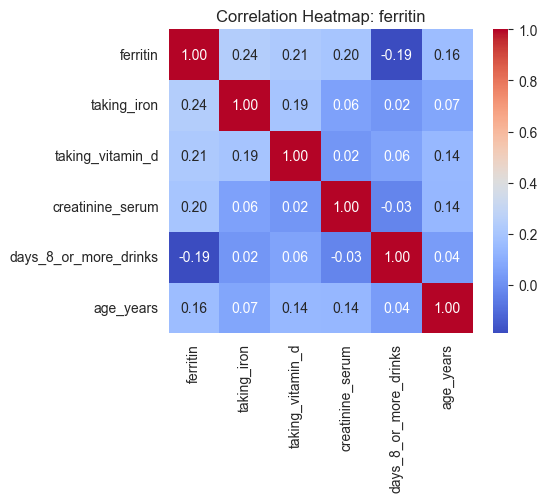

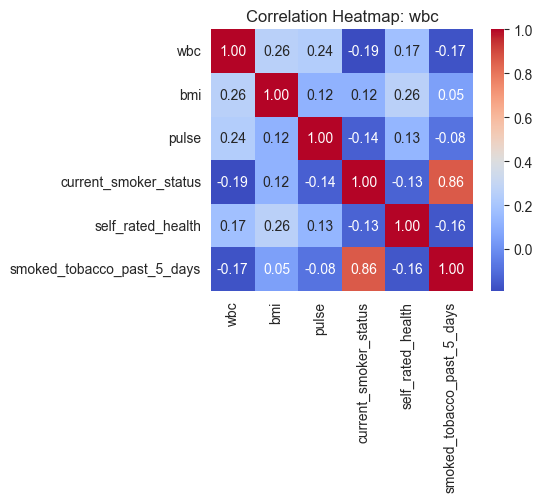

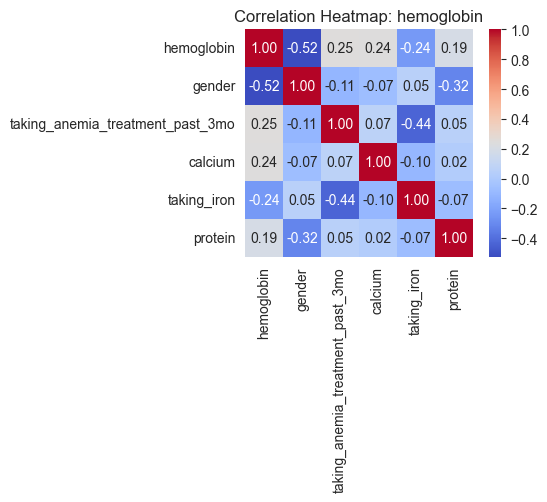

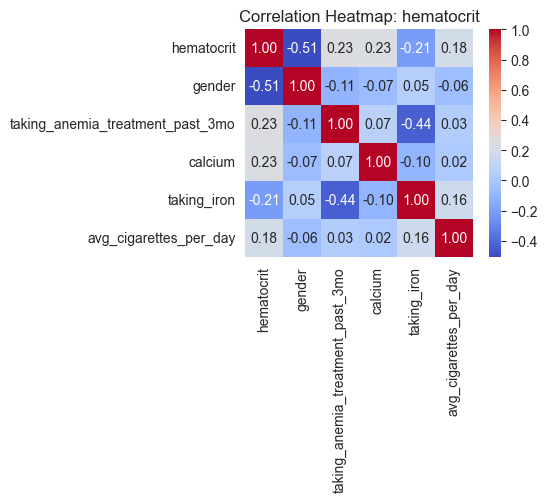

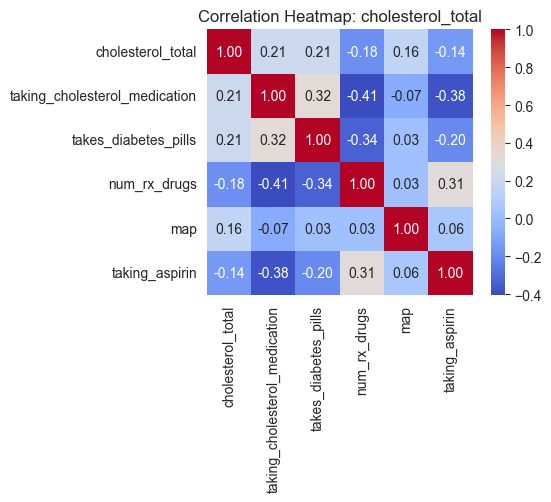

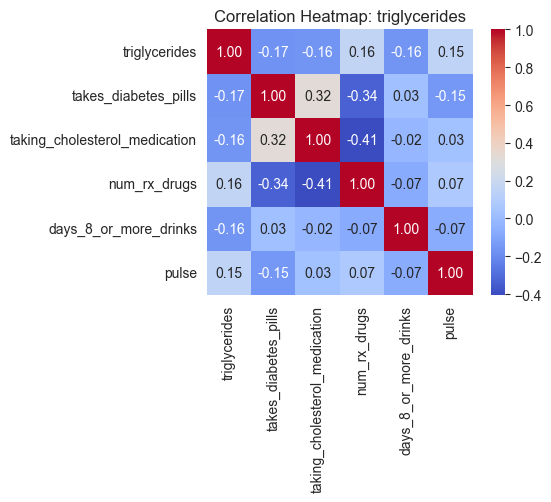

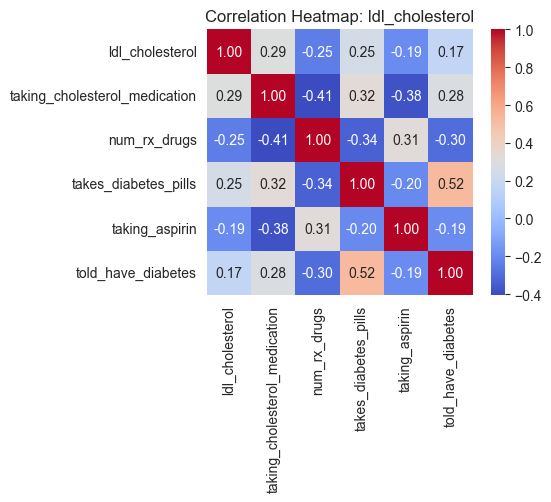

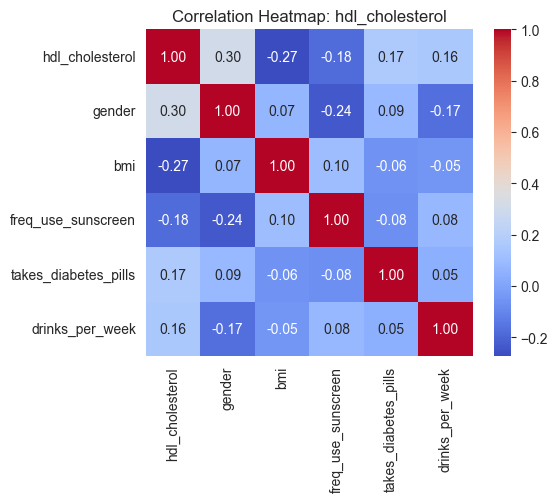

In [19]:
features = [col for col in df.columns if col not in tests]
corr_matrix = df[tests + features].corr(numeric_only=True)

for test in tests:
    top_features = (
        corr_matrix.loc[features, test]  # only look at non-targets
        .sort_values(key=lambda x: x.abs(), ascending=False)
        .head(5)
        .index
    )

    cols_to_plot = [test] + list(top_features)
    sub_corr = df[cols_to_plot].corr()

    plt.figure(figsize=(6, 5))
    sns.heatmap(sub_corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title(f"Correlation Heatmap: {test}")
    plt.tight_layout()
    plt.show()